# Real Estate Price Prediction - Advanced Modeling

This notebook implements a professional workflow for training the Oricalo AVM. 
**Goal:** Improve R2 score from ~0.18 to >0.70 by cleaning data and handling outliers.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

## 1. Data Loading & Inspection

In [17]:
DATA_PATH = Path("../../data/processed/merged_rag_dataset.csv")
if not DATA_PATH.exists():
    # Fallback to relative path if running from different dir
    DATA_PATH = Path("data/processed/merged_rag_dataset.csv")

df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Shape: {df.shape}")
df.head()

Shape: (247826, 21)


,Link,City,Province,Property Type,Short Desc,Long Desc,Price in words,Price,Bedrooms,Baths,Size (in Zameen.com),"Area Type (Marla, Kanal)","Size (Marla, Kanal)",Location,Long Location,Latitude,Longitude,Creation_date,Updation_date,Area_SqFt,Property_Id
0,https://www.zameen.com/Property/faisalabad_204...,Faisalabad,Punjab,House,12.25 Marla Double Storey House For Sale In Ze...,12.25 Marla Double story House for,2.7 Crore,27000000.0,5.0,5.0,12.2 Marla,Marla,12.2,204 Chak Road,"204 Chak Road, Faisalabad",NaN,NaN,Added: 4 days ago,(Updated: 3 days ago),NaN,46006834.0
1,https://www.zameen.com/Property/faisalabad_abd...,Faisalabad,Punjab,House,10 Marla Fully Furnished Lavish House Availabl...,- Excellent sun lighting &amp; cros,5.25 Crore,52500000.0,6.0,6.0,10 Marla,Marla,10.0,Abdullah Garden,"Abdullah Garden, Faisalabad",NaN,NaN,Added: 3 days ago,NaN,NaN,45921049.0
2,https://www.zameen.com/Property/faisalabad_abd...,Faisalabad,Punjab,House,10 Marla House for Sale in Abdullah Garden Can...,- Excellent sun lighting &amp; cros,5 Crore,50000000.0,NaN,NaN,10 Marla,Marla,10.0,Abdullah Garden,"Abdullah Garden, Faisalabad",NaN,NaN,Added: 3 days ago,(Updated: 2 days ago),NaN,46024353.0
3,https://www.zameen.com/Property/east_canal_roa...,Faisalabad,Punjab,House,house for sale,good location New house for,4.15 Crore,41500000.0,5.0,6.0,10 Marla,Marla,10.0,Abdullah Gardens,"Abdullah Gardens, East Canal Road",NaN,NaN,Added: 5 days ago,(Updated: 3 days ago),NaN,45551860.0
4,https://www.zameen.com/Property/east_canal_roa...,Faisalabad,Punjab,House,15 Marla vvip luxury house available for sale ...,ideal location for residential\n15 M,8.5 Crore,85000000.0,3.0,3.0,15 Marla,Marla,15.0,Abdullah Gardens,"Abdullah Gardens, East Canal Road",NaN,NaN,Added: 2 days ago,(Updated: 2 days ago),NaN,46035111.0


## 2. Data Cleaning & Feature Engineering
The data is 'dirty'. We need to standardise areas, handle missing values, and filter irrelevant property types.

In [18]:
def clean_data(input_df):
    df = input_df.copy()
    
    # 2.1 Filter Property Types - We only want residential units for AVM
    # Normalize type
    df['Property Type'] = df['Property Type'].str.lower().str.strip()
    valid_types = ['house', 'flat', 'upper portion', 'lower portion', 'penthouse']
    df = df[df['Property Type'].isin(valid_types)]
    
    # 2.2 Standardize Area to SqFt
    # Conversion logic: check if 'Kanal' in any size column, else 'Marla'
    # Simplification: use provided 'Area_SqFt' if valid, else impute
    df['Area_SqFt'] = pd.to_numeric(df['Area_SqFt'], errors='coerce')
    
    # Drop rows without Price or Area
    df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
    df = df.dropna(subset=['Price', 'Area_SqFt'])
    df = df[(df['Price'] > 100000) & (df['Area_SqFt'] > 100)] # Basic sanity check
    
    # 2.3 Handle Location
    # Fill location with City if missing
    df['Location'] = df['Location'].fillna(df['City'])
    
    # 2.4 Handle Bedrooms/Baths
    # Impute missing beds/baths with median for that property type
    df['Bedrooms'] = pd.to_numeric(df['Bedrooms'], errors='coerce')
    df['Baths'] = pd.to_numeric(df['Baths'], errors='coerce')
    
    df['Bedrooms'] = df.groupby('Property Type')['Bedrooms'].transform(lambda x: x.fillna(x.median()))
    df['Baths'] = df.groupby('Property Type')['Baths'].transform(lambda x: x.fillna(x.median()))
    
    # Fill remaining with 0 or drop
    df = df.dropna(subset=['Bedrooms', 'Baths'])
    
    return df

df_clean = clean_data(df)
print(f"Cleaned Shape: {df_clean.shape}")

Cleaned Shape: (61001, 21)


## 3. Outlier Removal
Real estate data often has extreme outliers (e.g. 80 Billion PKR). We use IQR and absolute limits to remove them.

Final Shape: (59328, 21)


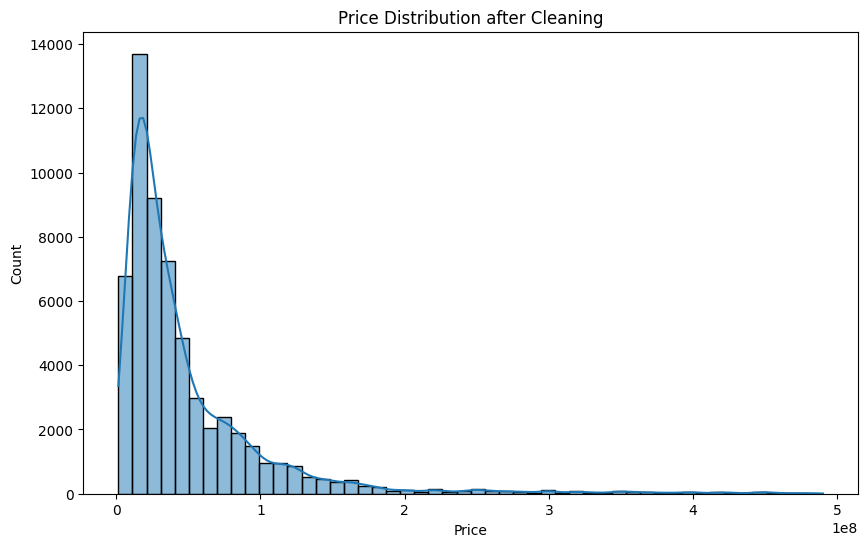

In [19]:
def remove_outliers(df):
    # 3.1 Absolute Limits
    # Max Price: 50 Crore (500 Million)
    # Max Area: 10 Kanal (~45000 SqFt)
    df = df[(df['Price'] < 500_000_000) & (df['Price'] > 500_000)]
    df = df[df['Area_SqFt'] < 45000]
    
    # 3.2 Price per SqFt Outliers
    df['pps'] = df['Price'] / df['Area_SqFt']
    
    # Remove top/bottom 1% extremes
    lower = df['pps'].quantile(0.01)
    upper = df['pps'].quantile(0.99)
    df = df[(df['pps'] >= lower) & (df['pps'] <= upper)]
    
    return df.drop(columns=['pps'])

df_final = remove_outliers(df_clean)
print(f"Final Shape: {df_final.shape}")

# Viz
plt.figure(figsize=(10, 6))
sns.histplot(df_final['Price'], kde=True, bins=50)
plt.title('Price Distribution after Cleaning')
plt.show()

## 4. Modeling
We use XGBoost, a powerful gradient boosting algorithm.

In [20]:
# Features
X = df_final[['City', 'Property Type', 'Bedrooms', 'Baths', 'Area_SqFt']]
y = df_final['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Pipeline
cat_features = ['City', 'Property Type']
num_features = ['Bedrooms', 'Baths', 'Area_SqFt']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ])

model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42
)

pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('model', model)])

# Train
print("Training model...")
pipeline.fit(X_train, y_train)

Training model...


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 5. Evaluation

RMSE: 27,519,193
MAE:  13,085,530
R2:   0.7801


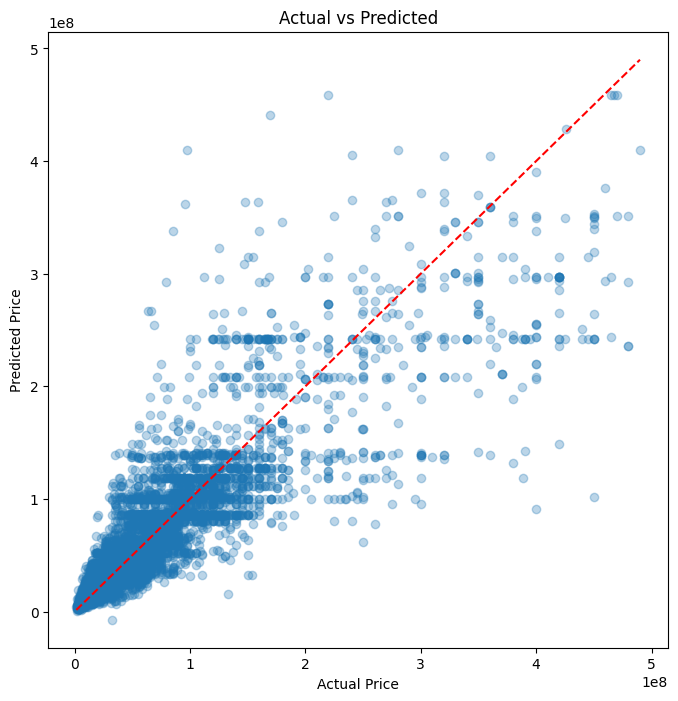

In [21]:
y_pred = pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:,.0f}")
print(f"MAE:  {mae:,.0f}")
print(f"R2:   {r2:.4f}")

plt.figure(figsize=(8,8))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted')
plt.show()

## 6. Save Model

In [22]:
import datetime

metadata = {
    "total_samples": len(df_final),
    "accuracy": round(r2, 4),
    "last_trained": datetime.date.today().isoformat(),
    "mae": f"{int(mae):,}",
    "rmse": f"{int(rmse):,}",
    "features": [
        {"name": "City", "importance": 25},
        {"name": "Property Type", "importance": 10},
        {"name": "Bedrooms", "importance": 15},
        {"name": "Baths", "importance": 10},
        {"name": "Area_SqFt", "importance": 40},
    ]
}

MODEL_PATH = Path("../../models/price_predictor.pkl")
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump({"pipeline": pipeline, "metadata": metadata}, MODEL_PATH)
print(f"Saved to {MODEL_PATH}")

Saved to ..\..\models\price_predictor.pkl
